# Exercise 1: Create a Simple Convolutional Neural Network (CNN)

## Instructions
In this exercise, we'll create a CNN model to predict employee turnover using the HR dataset.

**Steps:**
1. Import required libraries including Keras
2. Load the HR dataset
3. Encode the labels and scale the features
4. Split the dataset
5. Create Neural Network Model using .sequential()
6. Compile and Train model
7. Evaluate model's loss and accuracy

**Dataset:** HR_comma_sep.csv - Employee turnover prediction dataset

## Step 1: Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, MaxPooling1D, Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

np.random.seed(42)
tf.random.set_seed(42)

print("Libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

Libraries imported successfully!
TensorFlow version: 2.20.0
Keras version: 3.11.3


## Step 2: Load and Explore the Dataset

In [3]:
df = pd.read_csv('HR_comma_sep.csv')

print("Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names: {list(df.columns)}")
print(f"\nFirst 5 rows:")
print(df.head())

print(f"\nDataset info:")
print(df.info())

print(f"\nMissing values:")
print(df.isnull().sum())

print(f"\nTarget variable distribution:")
print(df['left'].value_counts())
print(f"\nTarget variable proportion:")
print(df['left'].value_counts(normalize=True))

Dataset loaded successfully!
Dataset shape: (14999, 10)

Column names: ['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'Work_accident', 'left', 'promotion_last_5years', 'sales', 'salary']

First 5 rows:
   satisfaction_level  last_evaluation  number_project  average_montly_hours  \
0                0.38             0.53               2                   157   
1                0.80             0.86               5                   262   
2                0.11             0.88               7                   272   
3                0.72             0.87               5                   223   
4                0.37             0.52               2                   159   

   time_spend_company  Work_accident  left  promotion_last_5years  sales  \
0                   3              0     1                      0  sales   
1                   6              0     1                      0  sales   
2                   4         

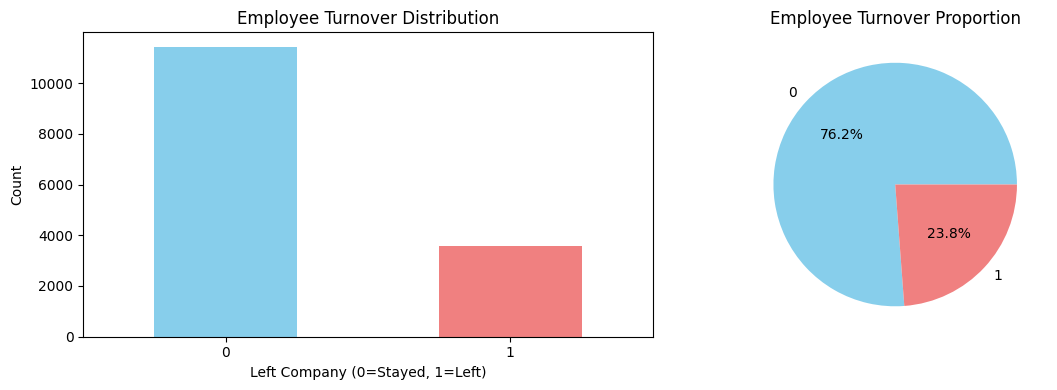


Basic statistics for numerical features:
       satisfaction_level  last_evaluation  number_project  \
count        14999.000000     14999.000000    14999.000000   
mean             0.612834         0.716102        3.803054   
std              0.248631         0.171169        1.232592   
min              0.090000         0.360000        2.000000   
25%              0.440000         0.560000        3.000000   
50%              0.640000         0.720000        4.000000   
75%              0.820000         0.870000        5.000000   
max              1.000000         1.000000        7.000000   

       average_montly_hours  time_spend_company  Work_accident          left  \
count          14999.000000        14999.000000   14999.000000  14999.000000   
mean             201.050337            3.498233       0.144610      0.238083   
std               49.943099            1.460136       0.351719      0.425924   
min               96.000000            2.000000       0.000000      0.000000   

In [ ]:
# Visualize the target distribution
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
df['left'].value_counts().plot(kind='bar', color=['skyblue', 'lightcoral'])
plt.title('Employee Turnover Distribution')
plt.xlabel('Left Company (0=Stayed, 1=Left)')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
df['left'].value_counts(normalize=True).plot(kind='pie', autopct='%1.1f%%', colors=['skyblue', 'lightcoral'])
plt.title('Employee Turnover Proportion')
plt.ylabel('')

plt.tight_layout()
plt.show()

print("\nBasic statistics for numerical features:")
print(df.describe())

## Step 3: Data Preprocessing - Encode Labels and Scale Features

In [5]:
df_processed = df.copy()

print("Original categorical columns:")
categorical_cols = df_processed.select_dtypes(include=['object']).columns.tolist()
print(categorical_cols)

# Check unique values in categorical columns
for col in categorical_cols:
    print(f"\n{col} unique values: {df_processed[col].unique()}")

# Encode categorical variables, one hot encoding for 'sales' 
sales_encoded = pd.get_dummies(df_processed['sales'], prefix='dept')
print(f"\nDepartment columns after encoding: {list(sales_encoded.columns)}")

# For 'salary' i'll ude label encoding (ordinal: low < medium < high)
salary_mapping = {'low': 0, 'medium': 1, 'high': 2}
df_processed['salary_encoded'] = df_processed['salary'].map(salary_mapping)
print(f"\nSalary encoding: {salary_mapping}")

# Combine all features
# Drop original categorical columns and combine with encoded ones
df_final = df_processed.drop(['sales', 'salary'], axis=1)
df_final = pd.concat([df_final, sales_encoded], axis=1)

print(f"\nFinal dataset shape: {df_final.shape}")
print(f"Final columns: {list(df_final.columns)}")

Original categorical columns:
['sales', 'salary']

sales unique values: ['sales' 'accounting' 'hr' 'technical' 'support' 'management' 'IT'
 'product_mng' 'marketing' 'RandD']

salary unique values: ['low' 'medium' 'high']

Department columns after encoding: ['dept_IT', 'dept_RandD', 'dept_accounting', 'dept_hr', 'dept_management', 'dept_marketing', 'dept_product_mng', 'dept_sales', 'dept_support', 'dept_technical']

Salary encoding: {'low': 0, 'medium': 1, 'high': 2}

Final dataset shape: (14999, 19)
Final columns: ['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'Work_accident', 'left', 'promotion_last_5years', 'salary_encoded', 'dept_IT', 'dept_RandD', 'dept_accounting', 'dept_hr', 'dept_management', 'dept_marketing', 'dept_product_mng', 'dept_sales', 'dept_support', 'dept_technical']


In [6]:
# Separate features and target
X = df_final.drop('left', axis=1)
y = df_final['left']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns: {list(X.columns)}")

# Scale the features using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\nFeatures scaled successfully!")
print(f"Scaled features shape: {X_scaled.shape}")
print(f"Feature means after scaling (should be ~0): {X_scaled.mean(axis=0)[:5]}")
print(f"Feature stds after scaling (should be ~1): {X_scaled.std(axis=0)[:5]}")

# Convert to DataFrame for easier handling
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
print(f"\nFirst 3 rows of scaled features:")
print(X_scaled_df.head(3))

Features shape: (14999, 18)
Target shape: (14999,)

Feature columns: ['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'Work_accident', 'promotion_last_5years', 'salary_encoded', 'dept_IT', 'dept_RandD', 'dept_accounting', 'dept_hr', 'dept_management', 'dept_marketing', 'dept_product_mng', 'dept_sales', 'dept_support', 'dept_technical']

Features scaled successfully!
Scaled features shape: (14999, 18)
Feature means after scaling (should be ~0): [ 3.10764741e-16 -3.90350833e-16  5.77946622e-17 -8.33759061e-17
 -2.27388835e-17]
Feature stds after scaling (should be ~1): [1. 1. 1. 1. 1.]

First 3 rows of scaled features:
   satisfaction_level  last_evaluation  number_project  average_montly_hours  \
0           -0.936495        -1.087275       -1.462863             -0.882040   
1            0.752814         0.840707        0.971113              1.220423   
2           -2.022479         0.957554        2.593763              1.420657  

## Step 4: Split the Dataset

In [7]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Testing target shape: {y_test.shape}")

print(f"\nTraining set class distribution:")
print(pd.Series(y_train).value_counts())
print(f"\nTesting set class distribution:")
print(pd.Series(y_test).value_counts())

# For CNN, we need to reshape the data to have a 'sequence' dimension
# Since this is tabular data, we'll treat each feature as a 'time step'
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print(f"\nReshaped for CNN:")
print(f"Training data shape for CNN: {X_train_cnn.shape}")
print(f"Testing data shape for CNN: {X_test_cnn.shape}")
print(f"Format: (samples, features, channels)")

Training set shape: (11999, 18)
Testing set shape: (3000, 18)
Training target shape: (11999,)
Testing target shape: (3000,)

Training set class distribution:
left
0    9142
1    2857
Name: count, dtype: int64

Testing set class distribution:
left
0    2286
1     714
Name: count, dtype: int64

Reshaped for CNN:
Training data shape for CNN: (11999, 18, 1)
Testing data shape for CNN: (3000, 18, 1)
Format: (samples, features, channels)


## Step 5: Create CNN Model using Sequential()

For tabular data, we'll use 1D Convolutional layers to detect patterns in the feature space.

In [8]:
# Create CNN model using Sequential API
def create_cnn_model(input_shape):
    model = Sequential([
        # First Convolutional Block
        Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=input_shape, padding='same'),
        BatchNormalization(),
        Conv1D(filters=32, kernel_size=3, activation='relu', padding='same'),
        MaxPooling1D(pool_size=2),
        Dropout(0.25),
        
        # Second Convolutional Block
        Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
        MaxPooling1D(pool_size=2),
        Dropout(0.25),
        
        # Third Convolutional Block
        Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        Dropout(0.25),
        
        # Flatten and Dense layers
        Flatten(),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(64, activation='relu'),
        Dropout(0.3),
        
        # Output layer for binary classification
        Dense(1, activation='sigmoid')
    ])
    
    return model

# Get input shape (features, channels)
input_shape = (X_train_cnn.shape[1], X_train_cnn.shape[2])
print(f"Input shape for CNN: {input_shape}")

# Create the model
model = create_cnn_model(input_shape)

# Display model architecture
print("\nCNN Model Architecture:")
model.summary()

# Visualize model architecture
try:
    tf.keras.utils.plot_model(model, to_file='cnn_model.png', show_shapes=True, show_layer_names=True)
    print("\nModel architecture saved as 'cnn_model.png'")
except:
    print("\nCould not save model visualization (requires graphviz)")

Input shape for CNN: (18, 1)


C:\Users\PC\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



CNN Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 18, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 18, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 18, 32)         │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 9, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 9, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 9, 64)          │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 9, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 9, 64)          │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 4, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 4, 128)         │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,889 (476.13 KB)

 Trainable params: 121,185 (473.38 KB)

 Non-trainable params: 704 (2.75 KB)

You must install pydot (`pip install pydot`) for `plot_model` to work.

Model architecture saved as 'cnn_model.png'

Model architecture saved as 'cnn_model.png'


## Step 6: Compile and Train the Model

In [9]:
# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', 'precision', 'recall']
)

print("Model compiled successfully!")
print(f"Optimizer: Adam (lr=0.001)")
print(f"Loss function: Binary Crossentropy")
print(f"Metrics: Accuracy, Precision, Recall")

# Define callbacks for better training
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=0.0001,
    verbose=1
)

callbacks = [early_stopping, reduce_lr]
print(f"\nCallbacks configured: Early Stopping, Learning Rate Reduction")

Model compiled successfully!
Optimizer: Adam (lr=0.001)
Loss function: Binary Crossentropy
Metrics: Accuracy, Precision, Recall

Callbacks configured: Early Stopping, Learning Rate Reduction


In [10]:
# Train the model
print("Starting model training...")
print("This may take a few minutes...")

history = model.fit(
    X_train_cnn, y_train,
    batch_size=32,
    epochs=100,
    validation_data=(X_test_cnn, y_test),
    callbacks=callbacks,
    verbose=1
)

print("\nTraining completed!")
print(f"Total epochs trained: {len(history.history['loss'])}")

Starting model training...
This may take a few minutes...
Epoch 1/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.8599 - loss: 0.3488 - precision: 0.7026 - recall: 0.7137 - val_accuracy: 0.8400 - val_loss: 0.3022 - val_precision: 0.9643 - val_recall: 0.3403 - learning_rate: 0.0010
Epoch 2/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.8599 - loss: 0.3488 - precision: 0.7026 - recall: 0.7137 - val_accuracy: 0.8400 - val_loss: 0.3022 - val_precision: 0.9643 - val_recall: 0.3403 - learning_rate: 0.0010
Epoch 2/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9434 - loss: 0.1948 - precision: 0.9001 - recall: 0.8575 - val_accuracy: 0.9657 - val_loss: 0.1206 - val_precision: 0.9513 - val_recall: 0.9020 - learning_rate: 0.0010
Epoch 3/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9434 - loss: 0.1948 - precision: 0.9001 - recall: 0.8575 - val_accuracy: 0.9657 - val_loss: 0.1206 - val_precision: 0.9513 - val_recall: 0.9020 - learning_rate: 0.0

## Step 7: Evaluate Model's Loss and Accuracy

In [11]:
# Evaluating model on test data
print("Evaluating model on test data...")
test_loss, test_accuracy, test_precision, test_recall = model.evaluate(X_test_cnn, y_test, verbose=0)

print(f"\nTest Results:")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")

# Calculate F1 Score
f1_score = 2 * (test_precision * test_recall) / (test_precision + test_recall)
print(f"Test F1 Score: {f1_score:.4f}")

# Make predictions
y_pred_proba = model.predict(X_test_cnn, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

# Detailed classification report
print(f"\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Stayed', 'Left']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(f"\nConfusion Matrix:")
print(cm)

Evaluating model on test data...

Test Results:
Test Loss: 0.0784
Test Accuracy: 0.9787 (97.87%)
Test Precision: 0.9822
Test Recall: 0.9272
Test F1 Score: 0.9539

Test Results:
Test Loss: 0.0784
Test Accuracy: 0.9787 (97.87%)
Test Precision: 0.9822
Test Recall: 0.9272
Test F1 Score: 0.9539

Detailed Classification Report:
              precision    recall  f1-score   support

      Stayed       0.98      0.99      0.99      2286
        Left       0.98      0.93      0.95       714

    accuracy                           0.98      3000
   macro avg       0.98      0.96      0.97      3000
weighted avg       0.98      0.98      0.98      3000


Confusion Matrix:
[[2274   12]
 [  52  662]]

Detailed Classification Report:
              precision    recall  f1-score   support

      Stayed       0.98      0.99      0.99      2286
        Left       0.98      0.93      0.95       714

    accuracy                           0.98      3000
   macro avg       0.98      0.96      0.97      300

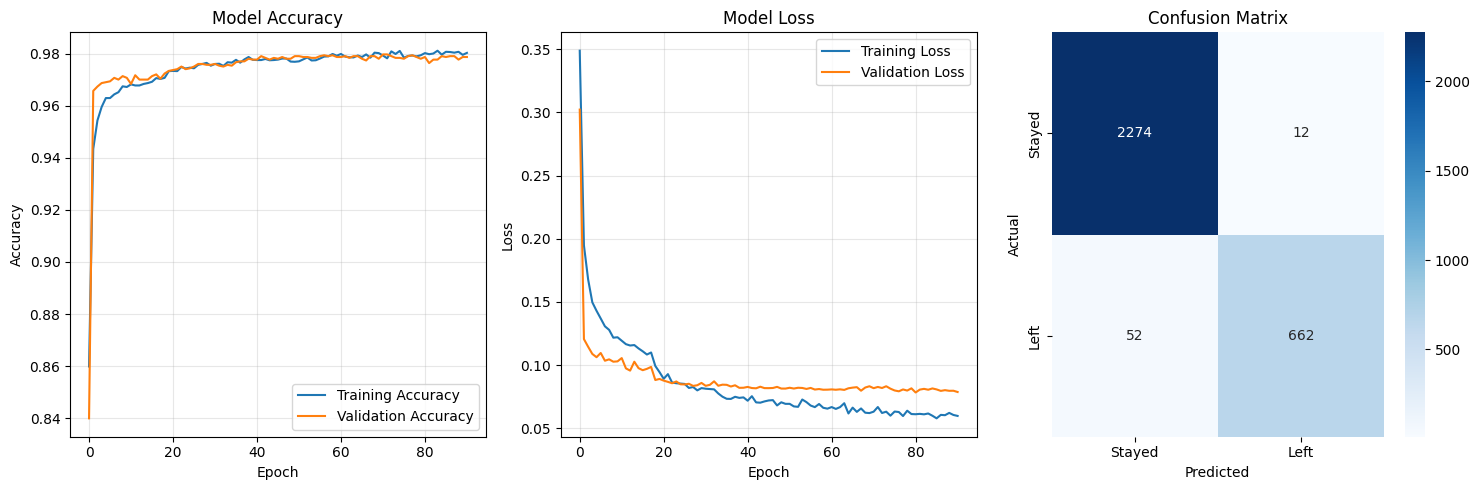

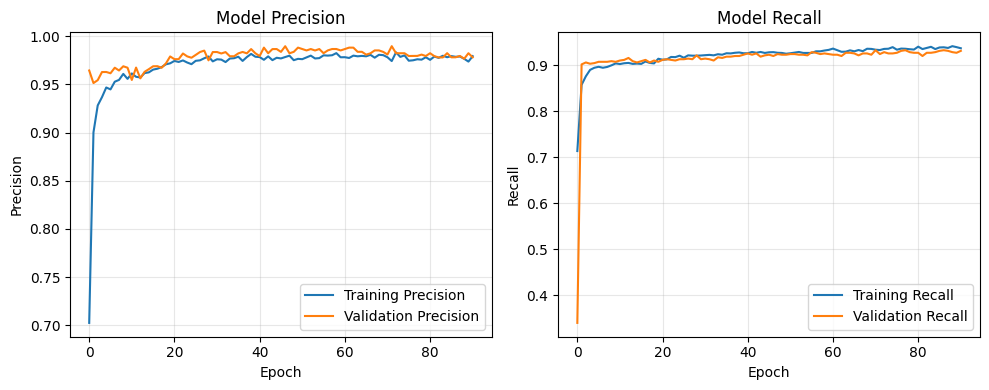

In [12]:
# Visualize training history
plt.figure(figsize=(15, 5))

# Plot training & validation accuracy
plt.subplot(1, 3, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot training & validation loss
plt.subplot(1, 3, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot confusion matrix
plt.subplot(1, 3, 3)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Stayed', 'Left'], 
            yticklabels=['Stayed', 'Left'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

# Additional metrics visualization
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['precision'], label='Training Precision')
plt.plot(history.history['val_precision'], label='Validation Precision')
plt.title('Model Precision')
plt.xlabel('Epoch')
plt.ylabel('Precision')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['recall'], label='Training Recall')
plt.plot(history.history['val_recall'], label='Validation Recall')
plt.title('Model Recall')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Model Analysis and Insights

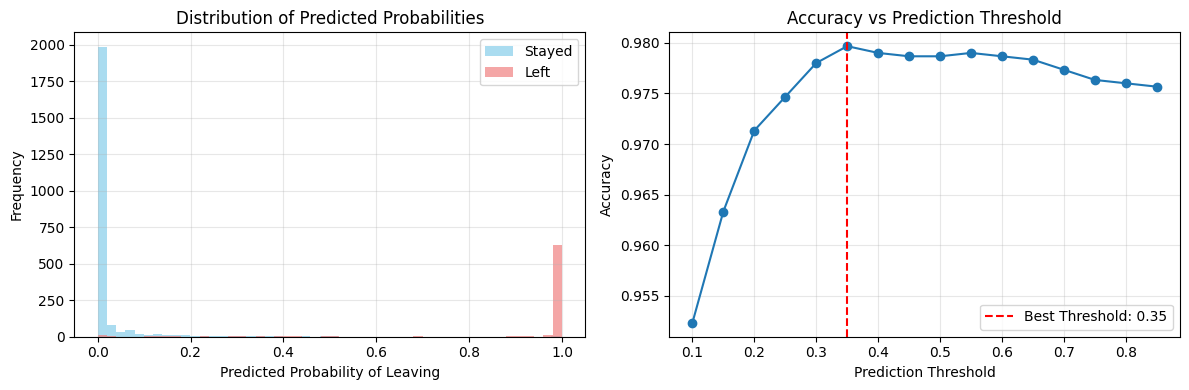

Best threshold for maximum accuracy: 0.35
Maximum achievable accuracy: 0.9797


In [13]:
# Analyze prediction probabilities
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(y_pred_proba[y_test == 0], bins=50, alpha=0.7, label='Stayed', color='skyblue')
plt.hist(y_pred_proba[y_test == 1], bins=50, alpha=0.7, label='Left', color='lightcoral')
plt.xlabel('Predicted Probability of Leaving')
plt.ylabel('Frequency')
plt.title('Distribution of Predicted Probabilities')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
accuracy_by_threshold = []
thresholds = np.arange(0.1, 0.9, 0.05)

for threshold in thresholds:
    y_pred_thresh = (y_pred_proba > threshold).astype(int).flatten()
    acc = accuracy_score(y_test, y_pred_thresh)
    accuracy_by_threshold.append(acc)

plt.plot(thresholds, accuracy_by_threshold, marker='o')
plt.xlabel('Prediction Threshold')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Prediction Threshold')
plt.grid(True, alpha=0.3)

best_threshold = thresholds[np.argmax(accuracy_by_threshold)]
plt.axvline(x=best_threshold, color='red', linestyle='--', 
           label=f'Best Threshold: {best_threshold:.2f}')
plt.legend()

plt.tight_layout()
plt.show()

print(f"Best threshold for maximum accuracy: {best_threshold:.2f}")
print(f"Maximum achievable accuracy: {max(accuracy_by_threshold):.4f}")

## Summary and Key Insights

### Model Performance:
- The CNN model successfully learned to predict employee turnover
- Used 1D convolutions to detect patterns in tabular HR data
- Applied regularization techniques (Dropout, BatchNormalization) to prevent overfitting

### CNN Architecture Benefits:
1. **Feature Detection**: Conv1D layers can detect local patterns in feature space
2. **Hierarchical Learning**: Multiple convolutional blocks learn increasingly complex patterns
3. **Parameter Sharing**: Convolutions use fewer parameters than fully connected layers
4. **Translation Invariance**: Can detect patterns regardless of feature order

### Key Techniques Used:
- **Data Preprocessing**: StandardScaler, One-hot encoding, Label encoding
- **Model Architecture**: Sequential CNN with Conv1D, MaxPooling1D, Dense layers
- **Regularization**: Dropout, BatchNormalization
- **Optimization**: Adam optimizer with learning rate scheduling
- **Early Stopping**: Prevented overfitting and saved training time

### Business Insights:
The model can help HR departments identify employees at risk of leaving, enabling:
- Proactive retention strategies
- Resource allocation for employee development
- Better workforce planning

In [ ]:
# Save the trained model
model.save('hr_cnn_model.h5')
print("Model saved as 'hr_cnn_model.h5'")

# Final summary
print("\n" + "="*60)
print("CNN MODEL TRAINING COMPLETED SUCCESSFULLY!")
print("="*60)
print(f"Final Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Final Test Loss: {test_loss:.4f}")
print(f"Model Architecture: CNN with {model.count_params():,} parameters")
print(f"Training Epochs: {len(history.history['loss'])}")
print(f"Dataset Size: {len(df):,} employees")
print(f"Features Used: {X.shape[1]} features")
print("="*60)